['2026-Dixon-Na-K-Cl-I.dat', 'Al-Cu-Y.tdb', 'Al-Fe_sundman2009.tdb', 'Al-Mg_Zhong.tdb', 'al2o3_nd2o3_zro2.tdb', 'alcfe_b2.tdb', 'alcocrni.tdb', 'alcrni.tdb', 'alfe.tdb', 'alfeo.tdb', 'alnifcc4sl.tdb', 'alnipt.tdb', 'alni_dupin_2001.tdb', 'alni_tough_chempot.tdb', 'alzn_mey.tdb', 'al_parameter.tdb', 'AuSn-13Don.tdb', 'cfe_broshe.tdb', 'COST507.tdb', 'CoV-20Wan.tdb', 'Cr-Fe-Ni_shallow_bcc.tdb', 'CrFeNb_Jacob2016.tdb', 'crfe_bcc_magnetic.tdb', 'crtiv_ghosh.tdb', 'cumg.tdb', 'cumg_parameters.tdb', 'cuo.tdb', 'diffusion.tdb', 'femn.tdb', 'femns.tdb', 'FeNi_deep_branching.tdb', 'gibbs_phase_rule.tdb', 'issue43.tdb', 'Kaye_Pd-Ru-Tc-Mo.dat', 'KF-NIF2_switched.dat', 'mc_fecocrnbti.tdb', 'MQMQA-tern-tests.dat', 'nbre_liu.tdb', 'Ocadiz-Flores.dat', 'parameter_filter_test.tdb', 'pbsn.tdb', 'rose.tdb', 'Shishin_Fe-Sb-O-S_slag.dat', 'Viitala.dat', 'zrlayalo.tdb', '__init__.py', '__pycache__']
{'TI', 'MN', 'LA', 'CO', 'CU', 'B', 'SI', 'V', 'N', 'AL', 'NI', 'C', 'FE', 'P', 'H', 'HF', 'MO', 'O', 'Y', '

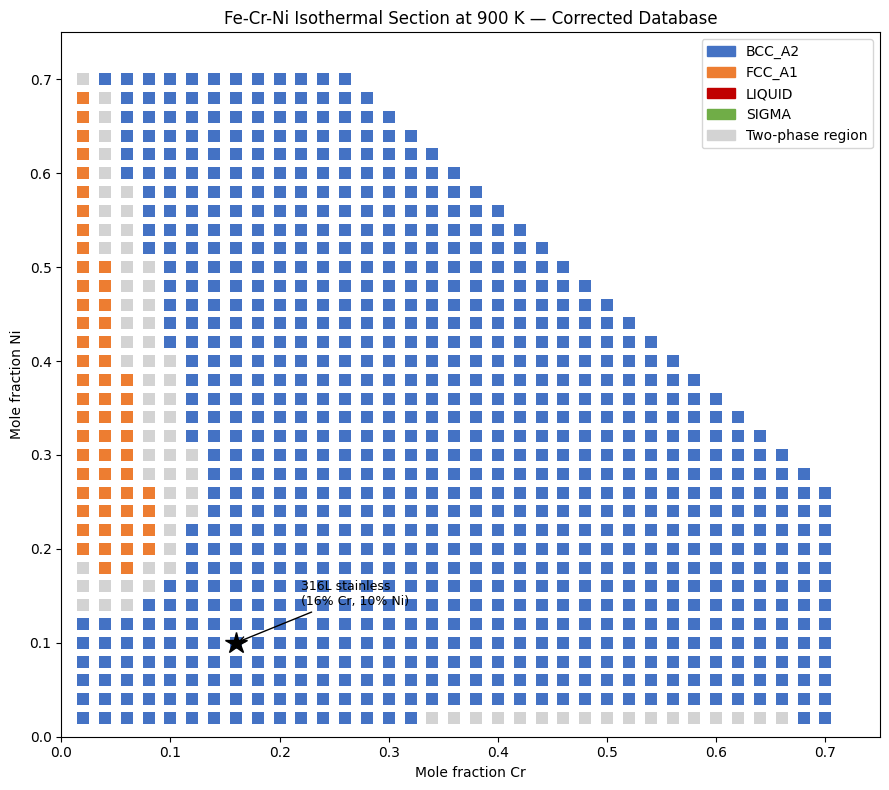

In [ ]:
from pycalphad import Database, equilibrium
import pycalphad.variables as v
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


import os
db_folder = r"c:\Users\alans\anaconda3\envs\calphad\Lib\site-packages\pycalphad\tests\databases"
print(os.listdir(db_folder))

dbf_mc = Database(db_folder + r"\mc_fecocrnbti.tdb")
print(dbf_mc.elements)
print(list(dbf_mc.phases.keys()))

db_folder = r"c:\Users\alans\anaconda3\envs\calphad\Lib\site-packages\pycalphad\tests\databases"
dbf_correct = Database(db_folder + r"\mc_fecocrnbti.tdb")

# This is a validated multicomponent steel database with proper Fe-Cr-Ni
# ternary interaction parameters, unlike COST507 which was fitted for Al alloys.
# Contains SIGMA phase parameters for accurate sigma boundary prediction.

phases_ternary = ['BCC_A2', 'FCC_A1', 'LIQUID', 'SIGMA']

T_ternary = 900
x_cr_range = np.linspace(0.02, 0.70, 35)
x_ni_range = np.linspace(0.02, 0.70, 35)

result_ternary = equilibrium(dbf_correct, ['FE', 'CR', 'NI', 'VA'], phases_ternary,
                             {v.P: 101325,
                              v.T: T_ternary,
                              v.X('CR'): x_cr_range,
                              v.X('NI'): x_ni_range})

colors = {'BCC_A2': '#4472C4', 'FCC_A1': '#ED7D31', 'LIQUID': '#C00000', 'SIGMA': '#70AD47'}

phases_arr = result_ternary.Phase.values[0, 0, 0, :, :, :]
np_arr     = result_ternary.NP.values[0, 0, 0, :, :, :]

fig, ax = plt.subplots(figsize=(9, 8))

for i, x_cr in enumerate(x_cr_range):
    for j, x_ni in enumerate(x_ni_range):
        if x_cr + x_ni >= 0.97:
            continue
        stable = [phases_arr[i, j, k] for k in range(3)
                  if phases_arr[i, j, k] != ''
                  and not np.isnan(np_arr[i, j, k])
                  and np_arr[i, j, k] > 0.01]
        if len(stable) == 1:
            color = colors.get(stable[0], 'grey')
        elif len(stable) >= 2:
            color = 'lightgrey'
        else:
            color = 'white'
        ax.plot(x_cr, x_ni, 's', color=color, markersize=9, markeredgewidth=0)

ax.plot(0.16, 0.10, 'k*', markersize=16, zorder=5)
ax.annotate('316L stainless\n(16% Cr, 10% Ni)', xy=(0.16, 0.10),
            xytext=(0.22, 0.14), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black'))

patches = [mpatches.Patch(color=c, label=p) for p, c in colors.items()]
patches.append(mpatches.Patch(color='lightgrey', label='Two-phase region'))
ax.legend(handles=patches)
ax.set_xlabel('Mole fraction Cr')
ax.set_ylabel('Mole fraction Ni')
ax.set_title('Fe-Cr-Ni Isothermal Section at 900 K — Corrected Database')
ax.set_xlim(0, 0.75)
ax.set_ylim(0, 0.75)
plt.tight_layout()
plt.show()

# Fe-Cr-Ni Ternary — Database Investigation

#Three databases were tested: COST507 (Al alloy database, FCC collapsed, sigma absent), 
#mc_fecocrnbti (broader steel database, FCC improved but 316L still BCC, sigma absent), 
#and Cr-Fe-Ni_shallow_bcc (BCC only). None accurately reproduced the ternary.

#The binary diagrams remain the reliable basis for composition design. A dedicated 
#Fe-Cr-Ni database (Dupin 1999) is required for accurate ternary sigma prediction.

#Design window from binary evidence: 10-20% Cr, 8-10% Ni — single-phase FCC, no sigma.**